In [1]:
import os
from keras import Sequential 
from keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam
from keras.regularizers import l2
import pandas as pd
from utils import compare_poly, get_season, compare_models, plot_error_curves
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# Load the data
kpi_df = pd.read_feather('../data/counting_df_by_site.feather')
weather_df = pd.read_feather('../data/weather_burbank_airport.feather')

In [3]:
kpi_df.head()

,siteID,local_hour,session_count
0,1,2018-10-08 06:00:00-07:00,4
1,1,2018-10-08 07:00:00-07:00,19
2,1,2018-10-08 08:00:00-07:00,19
3,1,2018-10-08 09:00:00-07:00,19
4,1,2018-10-08 10:00:00-07:00,19


In [4]:
weather_df.head()

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,Burbank,2018-01-01 00:53:00-08:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0,2018-01-01 01:00:00-08:00
1,Burbank,2018-01-01 01:53:00-08:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0,2018-01-01 02:00:00-08:00
2,Burbank,2018-01-01 02:53:00-08:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0,2018-01-01 03:00:00-08:00
3,Burbank,2018-01-01 03:53:00-08:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0,2018-01-01 04:00:00-08:00
4,Burbank,2018-01-01 04:53:00-08:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0,2018-01-01 05:00:00-08:00


### Data Preprocessing

In [5]:
# Take only charging data from the beginnnig of 2018 to March 2020 (before the pandemic)
kpi_df = kpi_df[(kpi_df["local_hour"] >= "2018-01-01") & (kpi_df["local_hour"] < "2020-03-01")]

The kpi_df contains the aggregated data of the charging sessions with the column session_count which contains the number of vehicles which were connected in that hour. However, it does not contain the hours in which no vehicles were connected. Therefore, we have to add these hours to the dataframe and fill the session_count column with 0 to be able to predict the hourly utilization.

In [6]:
# Compare the number of rows with the expected number of rows (all hours between the first and last timestamp times two)
full_range = pd.date_range(
    start=kpi_df['local_hour'].min(),
    end=kpi_df['local_hour'].max(),
    freq='h',
    tz=kpi_df['local_hour'].dt.tz
)
print(f"Expected rows: {len(full_range) * 2}")
print(f"Actual rows: {len(kpi_df)}")

Expected rows: 32434
Actual rows: 24003


In [7]:
# Add the missing hours
site_ids = kpi_df['siteID'].unique()
full_index = pd.MultiIndex.from_product(
    [site_ids, full_range],
    names=["siteID", "local_hour"]
)
full_kpi_df = pd.DataFrame(index=full_index).reset_index()

# Merge the original data with the expanded DataFrame
full_kpi_df = full_kpi_df.merge(kpi_df, on=["siteID", "local_hour"], how="left").fillna({'session_count': 0})
full_kpi_df['session_count'] = full_kpi_df['session_count'].astype(int)

In [8]:
print(f"Expected rows: {len(full_range) * 2}")
print(f"Actual rows: {len(full_kpi_df)}")

Expected rows: 32434
Actual rows: 32434


In [9]:
# Merge the two dataframes by timestamp
merged_df = kpi_df.merge(weather_df, left_on="local_hour", right_on="rounded_timestamp", how="left")
# merged_df = full_kpi_df.merge(weather_df, left_on="local_hour", right_on="rounded_timestamp", how="left")

In [10]:
merged_df.head()

,siteID,local_hour,session_count,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,1,2018-10-08 06:00:00-07:00,4,Burbank,2018-10-08 05:53:00-07:00,14.0,33.0,Fair,982.20,0.0,0.0,14.0,2018-10-08 06:00:00-07:00
1,1,2018-10-08 07:00:00-07:00,19,Burbank,2018-10-08 06:53:00-07:00,13.0,34.0,Fair,982.53,0.0,0.0,13.0,2018-10-08 07:00:00-07:00
2,1,2018-10-08 08:00:00-07:00,19,Burbank,2018-10-08 07:53:00-07:00,15.0,30.0,Partly Cloudy,982.86,0.0,0.0,15.0,2018-10-08 08:00:00-07:00
3,1,2018-10-08 09:00:00-07:00,19,Burbank,2018-10-08 08:53:00-07:00,17.0,30.0,Partly Cloudy,983.19,0.0,0.0,17.0,2018-10-08 09:00:00-07:00
4,1,2018-10-08 10:00:00-07:00,19,Burbank,2018-10-08 09:53:00-07:00,18.0,34.0,Fair,983.19,6.0,0.0,18.0,2018-10-08 10:00:00-07:00


In [11]:
len(merged_df)

24004

In [12]:
# Check for null values
missing_values_merged = merged_df.isnull().sum()
missing_values_merged

siteID                      0
local_hour                  0
session_count               0
city                       56
timestamp                  56
temperature                56
cloud_cover                56
cloud_cover_description    56
pressure                   56
windspeed                  56
precipitation              56
felt_temperature           56
rounded_timestamp          56
dtype: int64

There are 92 rows with missing weather data. We will drop these rows to be able to train the models.

In [13]:
# Drop rows with missing weather data 
merged_df = merged_df.dropna()

In [14]:
len(merged_df)

23948

In [15]:
merged_df.head()

,siteID,local_hour,session_count,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,1,2018-10-08 06:00:00-07:00,4,Burbank,2018-10-08 05:53:00-07:00,14.0,33.0,Fair,982.20,0.0,0.0,14.0,2018-10-08 06:00:00-07:00
1,1,2018-10-08 07:00:00-07:00,19,Burbank,2018-10-08 06:53:00-07:00,13.0,34.0,Fair,982.53,0.0,0.0,13.0,2018-10-08 07:00:00-07:00
2,1,2018-10-08 08:00:00-07:00,19,Burbank,2018-10-08 07:53:00-07:00,15.0,30.0,Partly Cloudy,982.86,0.0,0.0,15.0,2018-10-08 08:00:00-07:00
3,1,2018-10-08 09:00:00-07:00,19,Burbank,2018-10-08 08:53:00-07:00,17.0,30.0,Partly Cloudy,983.19,0.0,0.0,17.0,2018-10-08 09:00:00-07:00
4,1,2018-10-08 10:00:00-07:00,19,Burbank,2018-10-08 09:53:00-07:00,18.0,34.0,Fair,983.19,6.0,0.0,18.0,2018-10-08 10:00:00-07:00


We have merged the data. Now we have to prepare it for the machine learning model by encoding and normalizing the data.
We define hourly utilization of the stations as the number of vehicles charged in that hour. Therefore, we will use the KPI session_count as the target variable for the model.

In [16]:
model_df = merged_df.copy()

In [17]:
# Calculate time related features
model_df["hour"] = model_df["local_hour"].dt.hour
model_df['is_weekend'] = model_df['local_hour'].dt.weekday >= 5
model_df["season"] = model_df["local_hour"].apply(get_season)
model_df["season_num"] = model_df["season"].map({"Spring": 1, "Summer": 2, "Autumn": 3, "Winter": 4})
model_df["weekday"] = model_df["local_hour"].dt.weekday
model_df["month"] = model_df["local_hour"].dt.month

In [18]:
# Drop columns that are not needed for the model
model_df = model_df.drop(columns=['timestamp', 'rounded_timestamp', "city", "felt_temperature", "local_hour"])

In [19]:
model_df.head()

,siteID,session_count,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,hour,is_weekend,season,season_num,weekday,month
0,1,4,14.0,33.0,Fair,982.20,0.0,0.0,6,False,Autumn,3,0,10
1,1,19,13.0,34.0,Fair,982.53,0.0,0.0,7,False,Autumn,3,0,10
2,1,19,15.0,30.0,Partly Cloudy,982.86,0.0,0.0,8,False,Autumn,3,0,10
3,1,19,17.0,30.0,Partly Cloudy,983.19,0.0,0.0,9,False,Autumn,3,0,10
4,1,19,18.0,34.0,Fair,983.19,6.0,0.0,10,False,Autumn,3,0,10


In [20]:
# Distribution of values in cloud_cover_description
model_df["cloud_cover_description"].value_counts()

cloud_cover_description
Fair                       14504
Cloudy                      3781
Partly Cloudy               2813
Mostly Cloudy               1442
Light Rain                   480
Haze                         428
Smoke                        117
Fog                          115
Rain                          76
Fair / Windy                  62
Heavy Rain                    46
Partly Cloudy / Windy         18
T-Storm                       12
Cloudy / Windy                12
Mostly Cloudy / Windy         10
Blowing Dust                  10
Light Rain / Windy             8
Thunder in the Vicinity        8
Heavy Rain / Windy             4
Heavy T-Storm                  2
Name: count, dtype: int64

Before One Hot Encoding, we have to check the distribution of the categorical data in the column cloud_cover_description. As it can be seen above, there are a high number of unique values, which will result in a high number of columns after one hot encoding. The higher the number of features/dimensions the longer will it take to train the model. Therefore, we will merge the "/ Windy" columns with the corresponding columns and only keep the most frequent categories.

In [21]:
# Merge the "/ Windy" columns with the corresponding columns
model_df['cloud_cover_description'] = model_df['cloud_cover_description'].str.split(' / Windy').str[0]

# Keep the most frequent categories and merge the rest into "Other"
threshold = 100
model_df.loc[model_df["cloud_cover_description"].value_counts()[model_df["cloud_cover_description"]].values < threshold, "cloud_cover_description"] = "Other"

model_df["cloud_cover_description"].value_counts()

cloud_cover_description
Fair             14566
Cloudy            3793
Partly Cloudy     2831
Mostly Cloudy     1452
Light Rain         488
Haze               428
Other              158
Smoke              117
Fog                115
Name: count, dtype: int64

In [22]:
# One hot encode categorical data
model_df = pd.get_dummies(model_df, columns=['season'], drop_first=True)
model_df = pd.get_dummies(model_df, columns=['cloud_cover_description'], drop_first=True)
model_df = pd.get_dummies(model_df, columns=['siteID'], drop_first=True)

In [23]:
cloud_cover_columns = [col for col in model_df.columns if col.startswith("cloud_cover_description")]

In [24]:
model_df.head()

,session_count,temperature,cloud_cover,pressure,windspeed,precipitation,hour,is_weekend,season_num,weekday,...,season_Winter,cloud_cover_description_Fair,cloud_cover_description_Fog,cloud_cover_description_Haze,cloud_cover_description_Light Rain,cloud_cover_description_Mostly Cloudy,cloud_cover_description_Other,cloud_cover_description_Partly Cloudy,cloud_cover_description_Smoke,siteID_2
0,4,14.0,33.0,982.20,0.0,0.0,6,False,3,0,...,False,True,False,False,False,False,False,False,False,False
1,19,13.0,34.0,982.53,0.0,0.0,7,False,3,0,...,False,True,False,False,False,False,False,False,False,False
2,19,15.0,30.0,982.86,0.0,0.0,8,False,3,0,...,False,False,False,False,False,False,False,True,False,False
3,19,17.0,30.0,983.19,0.0,0.0,9,False,3,0,...,False,False,False,False,False,False,False,True,False,False
4,19,18.0,34.0,983.19,6.0,0.0,10,False,3,0,...,False,True,False,False,False,False,False,False,False,False


In [25]:
# Encode boolean columns
bool_cols = cloud_cover_columns + ["is_weekend", "season_Spring", "season_Summer", "season_Winter", "siteID_2"]
numerical_cols = [col for col in model_df.columns if col not in bool_cols]
model_df[bool_cols] = model_df[bool_cols].astype(int)

In [26]:
model_df.head()

,session_count,temperature,cloud_cover,pressure,windspeed,precipitation,hour,is_weekend,season_num,weekday,...,season_Winter,cloud_cover_description_Fair,cloud_cover_description_Fog,cloud_cover_description_Haze,cloud_cover_description_Light Rain,cloud_cover_description_Mostly Cloudy,cloud_cover_description_Other,cloud_cover_description_Partly Cloudy,cloud_cover_description_Smoke,siteID_2
0,4,14.0,33.0,982.20,0.0,0.0,6,0,3,0,...,0,1,0,0,0,0,0,0,0,0
1,19,13.0,34.0,982.53,0.0,0.0,7,0,3,0,...,0,1,0,0,0,0,0,0,0,0
2,19,15.0,30.0,982.86,0.0,0.0,8,0,3,0,...,0,0,0,0,0,0,0,1,0,0
3,19,17.0,30.0,983.19,0.0,0.0,9,0,3,0,...,0,0,0,0,0,0,0,1,0,0
4,19,18.0,34.0,983.19,6.0,0.0,10,0,3,0,...,0,1,0,0,0,0,0,0,0,0


### Explainable Model (Polynomial Regression)

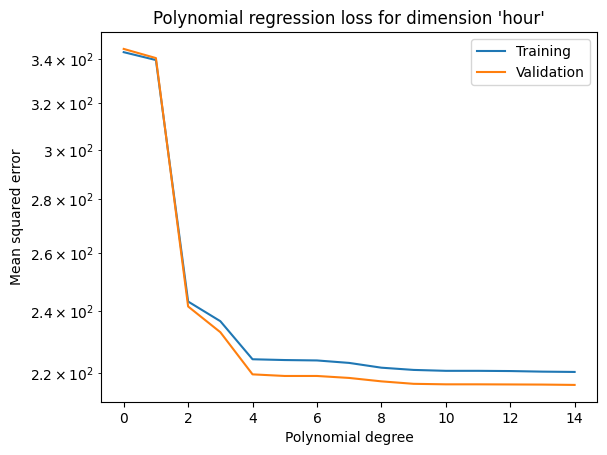

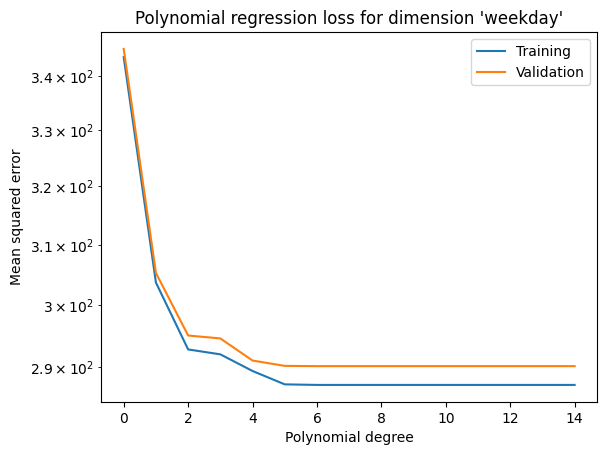

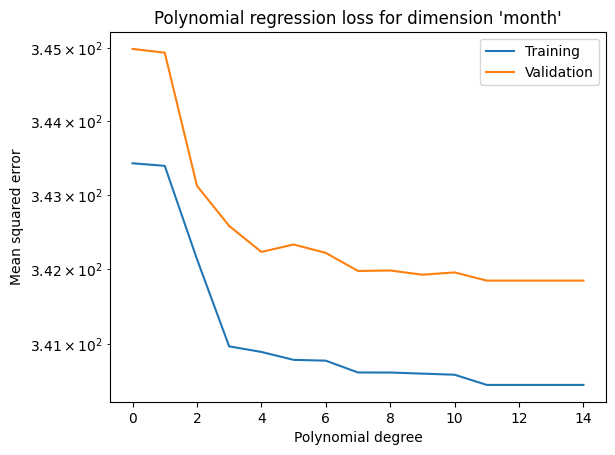

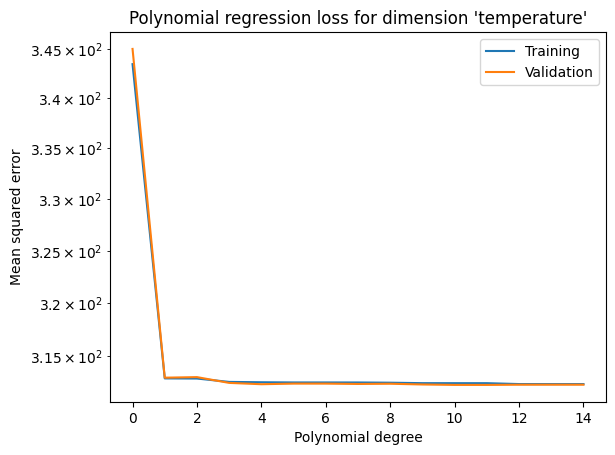

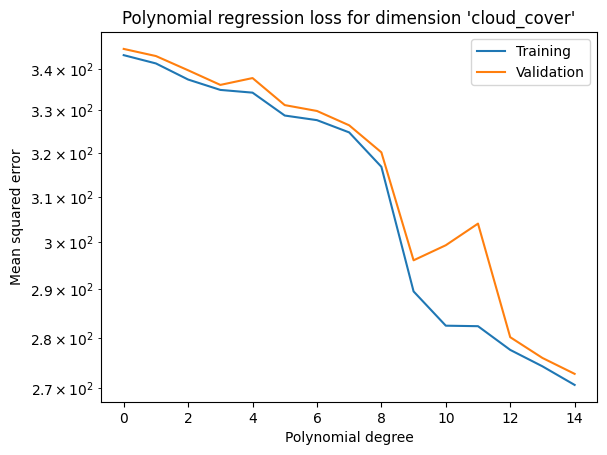

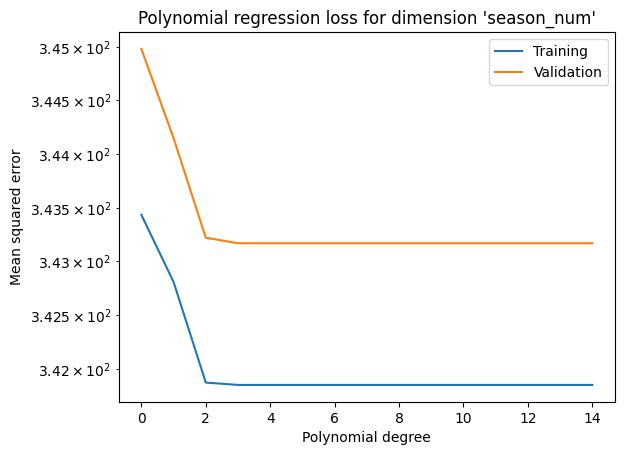

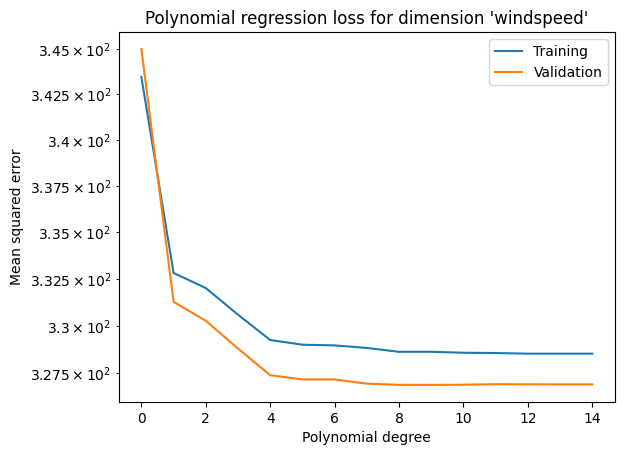

In [27]:
# Check which degree of polynomial regression is the best for each feature
comparison_cols = ["hour", "weekday", "month", "temperature", "cloud_cover", "season_num", "windspeed"]
for col in comparison_cols:
    plt.figure() 
    compare_poly(model_df, col, 'session_count', 15)
    plt.savefig(f"{col}_poly_comparison.png")
    plt.show()

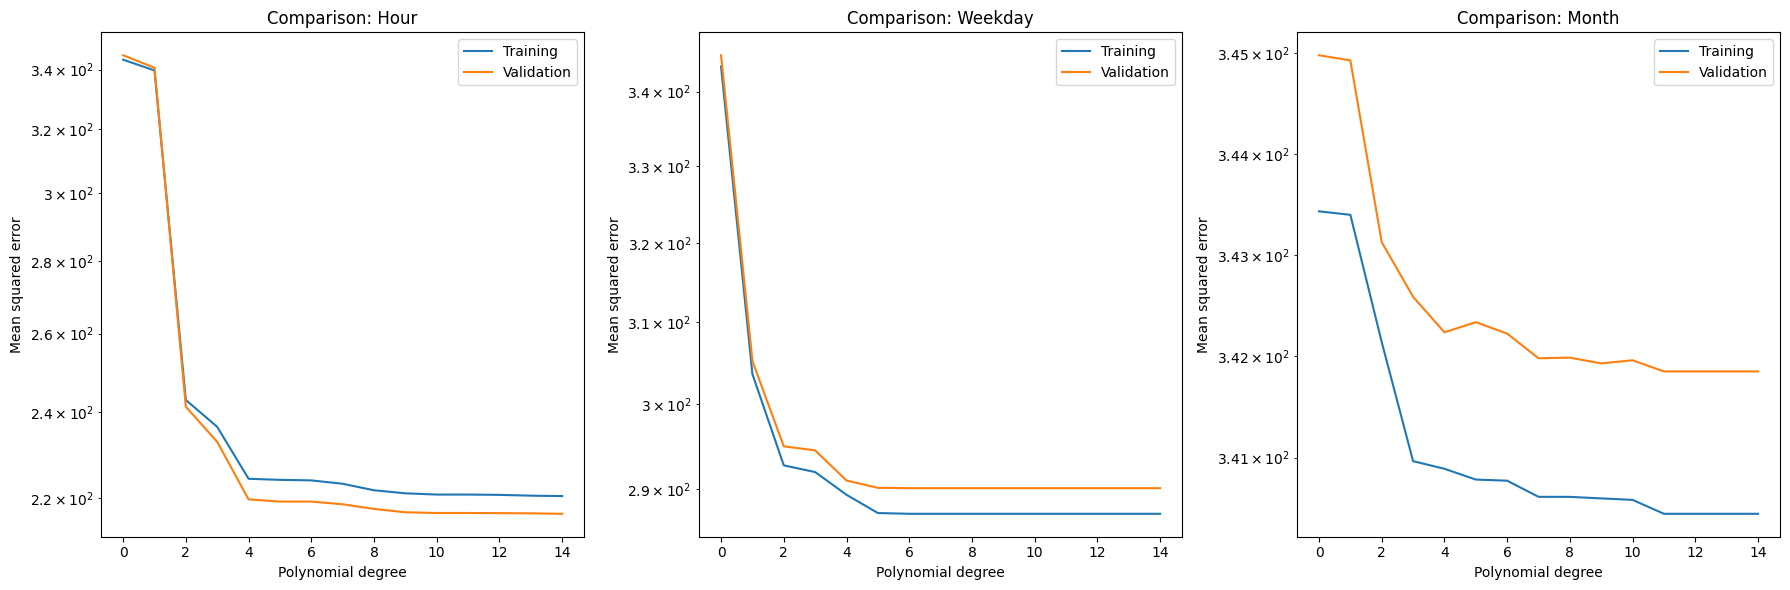

In [28]:
# Plot 3 plots next to each other
comparison_cols = ["hour", "weekday", "month"]
fig, axes = plt.subplots(1, len(comparison_cols), figsize=(18, 6))  # Create one row of subplots

for i, col in enumerate(comparison_cols):
    plt.sca(axes[i])  # Set the current axis
    compare_poly(model_df, col, 'session_count', 15)  
    axes[i].set_title(f"Comparison: {col.capitalize()}")  

plt.tight_layout()  
plt.show()

The plots above show the relationship between the target variable and the features by displaying the mean squared error for different polynomials. It can be seen that the relationship between the target variable and many features is not linear and the optimal polynomial degree seems to be 4.

In [29]:
# Split into two dataframes for the two siteIDs
model_df_site1 = model_df[model_df["siteID_2"] == 0]
model_df_site2 = model_df[model_df["siteID_2"] == 1]

In [30]:
def get_test_and_training_data(df, used_cols):
    """Get the test and training data for a model given a dataframe."""
    # Define the features and the target variable
    X = df[used_cols]
    y = df["session_count"]
    # Split the data into training and testing sets (80% train, 20% test)
    X_train_initial, X_test, y_train_initial, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, shuffle=True)
    return  X_train_initial, X_test, y_train_initial, y_test

In [31]:
def get_processed_data(X_train, X_test, used_columns_numerical, used_columns_boolean):
    """Scale the numerical columns of the data to for training."""
    # Column transformer to make sure to only scale the numerical columns
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), used_columns_numerical),
            ('bool', 'passthrough', used_columns_boolean)
        ]
    )
    # Fit and transform
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)
    return X_train_processed, X_test_processed

In [32]:
def create_polynomial_regression_model(X_train, y_train, X_test, y_test, degree):
    """Create a polynomial regression model and evaluate it."""
    # K-Fold Cross-Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Define model
    poly = PolynomialFeatures(degree=degree)
    linear_model = LinearRegression()
    
    # Lists to store evaluation metrics for each fold
    poly_mae_scores = []
    poly_rmse_scores = []
    poly_r2_scores = []

    # Perform K-Fold Cross-Validation 
    for train_index, val_index in kf.split(X_train):
        
        X_training, X_val = X_train[train_index], X_train[val_index]
        y_training, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
        
        # Transform the features into polynomial features and train model
        X_train_poly = poly.fit_transform(X_training)
        X_val_poly = poly.transform(X_val)
        linear_model.fit(X_train_poly, y_training)
        
        # Predict on the validation set
        y_pred_val = linear_model.predict(X_val_poly)
        
        # Calculate errors and R² for the fold
        mae = mean_absolute_error(y_val, y_pred_val)
        mse = mean_squared_error(y_val, y_pred_val)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_val, y_pred_val)
        poly_mae_scores.append(mae)
        poly_rmse_scores.append(rmse)
        poly_r2_scores.append(r2)
    
    # Transform the entire training and test sets
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Train model on the entire training set and predict on entire test set
    linear_model.fit(X_train_poly, y_train)
    y_pred_poly = linear_model.predict(X_test_poly)
    
    # Calculate errors and R² on the test set
    poly_mae = mean_absolute_error(y_test, y_pred_poly)
    poly_mse = mean_squared_error(y_test, y_pred_poly)
    poly_rmse = np.sqrt(poly_mse)
    poly_r2 = r2_score(y_test, y_pred_poly)
    
    # Print evaluation results
    print(f"Polynomial Regression (Degree 4) - Cross-validated MAE: {np.mean(poly_mae_scores):.4f}")
    print(f"Polynomial Regression (Degree 4) - Cross-validated RMSE: {np.mean(poly_rmse_scores):.4f}")
    print(f"Polynomial Regression (Degree 4) - Cross-validated R²: {np.mean(poly_r2_scores):.4f}")
    print(f"Polynomial Regression (Degree 4) - Test MAE: {poly_mae:.4f}")
    print(f"Polynomial Regression (Degree 4) - Test RMSE: {poly_rmse:.4f}")
    print(f"Polynomial Regression (Degree 4) - Test R²: {poly_r2:.4f}")
    return poly_mae, poly_rmse, poly_r2

In [33]:
def regression_pipeline(df, degree, used_cols):
    """Run the entire regression pipeline."""
    used_cols_numerical = [col for col in used_cols if col not in bool_cols]
    used_cols_boolean = [col for col in used_cols if col in bool_cols]
    X_train_initial, X_test, y_train_initial, y_test = get_test_and_training_data(df, used_cols)
    X_train_processed, X_test_processed = get_processed_data(
        X_train_initial, X_test, used_cols_numerical, used_cols_boolean)
    poly_mae, poly_rmse, poly_r2 = create_polynomial_regression_model(
        X_train_processed, y_train_initial, X_test_processed, y_test, degree)
    return poly_mae, poly_rmse, poly_r2

In [34]:
used_columns_sites_split_poly = ["hour", "weekday", "is_weekend", "temperature", "cloud_cover", "month", "season_Spring", "season_Summer", "season_Winter", "pressure"]
used_columns_both_sites_poly = ["hour", "weekday", "is_weekend", "season_Spring", "season_Summer", "season_Winter", "temperature", "cloud_cover", "month", "pressure", "siteID_2"]

In [35]:
print("Prediction results for site 1:")
poly_mae_site_1, poly_rmse_site_1, poly_r2_site_1 = regression_pipeline(
    model_df_site1, 4, used_columns_sites_split_poly)

Prediction results for site 1:
Polynomial Regression (Degree 4) - Cross-validated MAE: 6.8805
Polynomial Regression (Degree 4) - Cross-validated RMSE: 9.7111
Polynomial Regression (Degree 4) - Cross-validated R²: 0.8276
Polynomial Regression (Degree 4) - Test MAE: 6.6233
Polynomial Regression (Degree 4) - Test RMSE: 9.3004
Polynomial Regression (Degree 4) - Test R²: 0.8412


In [36]:
print("Prediction results for site 2:")
poly_mae_site_2, poly_rmse_site_2, poly_r2_site_2 = regression_pipeline(
    model_df_site2, 4, used_columns_sites_split_poly)

Prediction results for site 2:
Polynomial Regression (Degree 4) - Cross-validated MAE: 5.2325
Polynomial Regression (Degree 4) - Cross-validated RMSE: 6.9898
Polynomial Regression (Degree 4) - Cross-validated R²: 0.7388
Polynomial Regression (Degree 4) - Test MAE: 5.1707
Polynomial Regression (Degree 4) - Test RMSE: 6.9210
Polynomial Regression (Degree 4) - Test R²: 0.7439


In [37]:
print("Prediction results for both sites:")
poly_mae_all, poly_rmse_all, poly_r2_all = regression_pipeline(model_df, 4, used_columns_both_sites_poly)

Prediction results for both sites:
Polynomial Regression (Degree 4) - Cross-validated MAE: 6.1425
Polynomial Regression (Degree 4) - Cross-validated RMSE: 8.2624
Polynomial Regression (Degree 4) - Cross-validated R²: 0.8000
Polynomial Regression (Degree 4) - Test MAE: 6.1136
Polynomial Regression (Degree 4) - Test RMSE: 8.2381
Polynomial Regression (Degree 4) - Test R²: 0.8057


### Neural Network Model

In [38]:
os.environ["KERAS_BACKEND"] = "torch"

In [39]:
def create_neural_network_model(epochs, optimizer, x_nn, y_nn, cross_val=False):
    """Create a neural network model and evaluate it."""
    nn_model = Sequential([
        Input(shape=[x_nn.shape[1]]),
        Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
        Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
        Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
        Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
        Dense(1)
    ])
    
    if cross_val: 
        # K-Fold Cross-Validation
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        nn_mae_scores = []
        nn_rmse_scores = []
        nn_r2_scores = []
    
        for train_index, val_index in kf.split(x_nn):
            
            # Splitting the data
            X_training, X_val = x_nn[train_index], x_nn[val_index]
            y_training, y_val = y_nn.iloc[train_index], y_nn.iloc[val_index]
            
            # Compile the model
            nn_model.compile(loss='mse', optimizer=optimizer, metrics=["mae", "mse"])
            
            # Train the model
            nn_model.fit(X_training, y_training.values, epochs=epochs, verbose=0)
            
            # Predict on the validation set
            y_pred_val = nn_model.predict(X_val).flatten()
            
            # Calculate metrics for the fold
            mae = mean_absolute_error(y_val, y_pred_val)
            mse = mean_squared_error(y_val, y_pred_val)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_val, y_pred_val)
            nn_mae_scores.append(mae)
            nn_rmse_scores.append(rmse)
            nn_r2_scores.append(r2)
            
        print(f"Neural Network - Cross-validated MAE: {np.mean(nn_mae_scores):.4f}")
        print(f"Neural Network - Cross-validated RMSE: {np.mean(nn_rmse_scores):.4f}")
        print(f"Neural Network - Cross-validated R²: {np.mean(nn_r2_scores):.4f}")
    
    # Compiling the ANN
    nn_model.compile(loss='mse', optimizer=optimizer, metrics=["mae", "mse"])
    
    history = nn_model.fit(x_nn, y_nn.values,
                        epochs=epochs, 
                        validation_split=0.2, 
                        verbose=0)
    
    his_df = pd.DataFrame(history.history)
    return nn_model, his_df

In [40]:
def calculate_nn_metrics(model, X_test, y_test):
    """Calculate the MAE and R² for the neural network model."""
    y_pred_nn = model.predict(X_test)
    nn_mae = mean_absolute_error(y_test, y_pred_nn)
    nn_mse = mean_squared_error(y_test, y_pred_nn)
    nn_rmse = np.sqrt(nn_mse)
    nn_r2 = r2_score(y_test, y_pred_nn)
    print(f"Neural Network - Test MAE: {nn_mae:.4f}")
    print(f"Neural Network - Test RMSE: {nn_rmse:.4f}")
    print(f"Neural Network - Test R²: {nn_r2:.4f}")
    return nn_mae, nn_rmse, nn_r2

In [41]:
def neural_network_model_pipeline(df, epochs, optimizer, used_cols, calc_metrics=True, cross_val=False):
    """Run the entire neural network model pipeline."""
    used_cols_numerical = [col for col in used_cols if col not in bool_cols]
    used_cols_boolean = [col for col in used_cols if col in bool_cols]
    X_train_initial, X_test, y_train_initial, y_test = get_test_and_training_data(df, used_cols)
    X_train_processed, X_test_processed = get_processed_data(
        X_train_initial, X_test, used_cols_numerical, used_cols_boolean)
    model, history_df = create_neural_network_model(
        epochs, optimizer, X_train_processed, y_train_initial, cross_val
    )
    if calc_metrics:
        nn_mae, nn_rmse, nn_r2 = calculate_nn_metrics(model, X_test_processed, y_test)
        return nn_mae, nn_rmse, nn_r2
    else: 
        return history_df

In [42]:
used_columns_sites_split_nn = used_columns = ["hour", "weekday", "is_weekend", "season_Spring", "season_Summer", "season_Winter", "temperature", "cloud_cover", "month", "pressure"]
used_columns_both_sites_nn = ["hour", "weekday", "is_weekend", "season_Spring", "season_Summer", "season_Winter", "temperature", "cloud_cover", "month", "pressure", "siteID_2"]

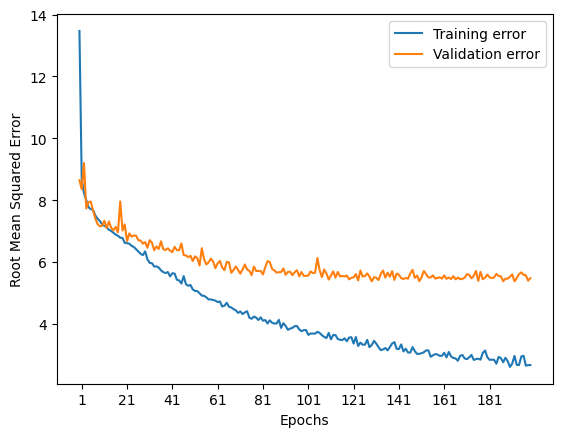

In [35]:
# Check for the best number of epochs
epoch_200_his_df = neural_network_model_pipeline(model_df, 200, Adam(), used_columns_both_sites_nn, calc_metrics=False)
plot_error_curves(1, 200, 20, epoch_200_his_df)

In [48]:
print("Prediction results for site 1:")
nn_mae_site_1, nn_rmse_site_1, nn_r2_site_1 = neural_network_model_pipeline(model_df_site1, 100, Adam(), used_columns_sites_split_nn, cross_val=True)

Prediction results for site 1:
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neural Network - Cross-validated MAE: 2.5419
Neural Network - Cross-validated RMSE: 4.7334
Neural Network - Cross-validated R²: 0.9551
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step
Neural Network - Test MAE: 2.5742
Neural Network - Test RMSE: 5.6652
Neural Network - Test R²: 0.9411


In [43]:
print("Prediction results for site 2:")
nn_mae_site_2, nn_rmse_site_2, nn_r2_site_2 = neural_network_model_pipeline(model_df_site2, 100, Adam(), used_columns_sites_split_nn, cross_val=True)

Prediction results for site 2:
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step
Neural Network - Cross-validated MAE: 2.7574
Neural Network - Cross-validated RMSE: 4.2715
Neural Network - Cross-validated R²: 0.8991
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step
Neural Network - Test MAE: 3.1497
Neural Network - Test RMSE: 5.2691
Neural Network - Test R²: 0.8516


In [44]:
print("Prediction results for both sites:")
nn_mae_all, nn_rmse_all, nn_r2_all = neural_network_model_pipeline(model_df, 100, Adam(), used_columns_both_sites_nn, cross_val=True)

Prediction results for both sites:
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step
Neural Network - Cross-validated MAE: 2.8571
Neural Network - Cross-validated RMSE: 4.5947
Neural Network - Cross-validated R²: 0.9352
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step
Neural Network - Test MAE: 3.0740
Neural Network - Test RMSE: 5.2532
Neural Network - Test R²: 0.9210


### Comparison of Models

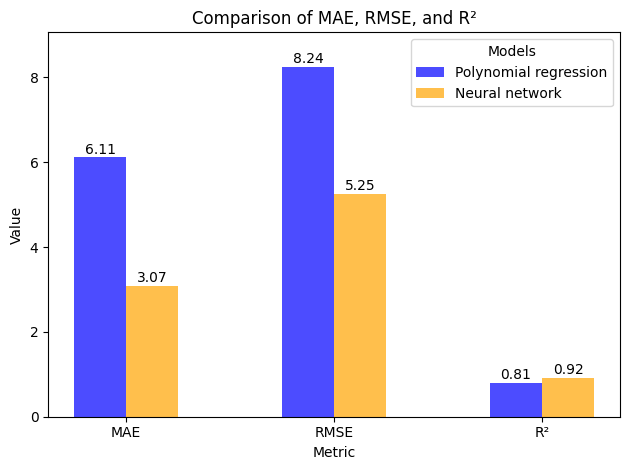

In [45]:
compare_models([poly_mae_all, poly_rmse_all, poly_r2_all], [nn_mae_all, nn_rmse_all, nn_r2_all])